# HW 3 — NER Fine-tuning with Transformers

Fine-tune a transformer encoder for Named Entity Recognition on FactRuEval 2016 dataset.
Explore multiple improvement strategies: MLM pre-training, advanced masking, and synthetic data augmentation.

## Environment Setup

This notebook is designed to run on Google Colab with a GPU runtime.
Alternatively, run locally with `uv sync --group hw_3` from the repo root.

In [1]:
%%capture
!pip install -q -U transformers datasets evaluate seqeval accelerate sentencepiece
!pip install -q -U scikit-learn seaborn matplotlib pandas tqdm

## Notebook Setup

In [2]:
import os
import re
import gc
import random
import warnings
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
from datasets import load_dataset, Dataset, DatasetDict, concatenate_datasets
import evaluate

from transformers import (
    AutoTokenizer,
    AutoModelForTokenClassification,
    AutoModelForMaskedLM,
    DataCollatorForTokenClassification,
    DataCollatorForLanguageModeling,
    DataCollatorForWholeWordMask,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
    pipeline,
)

from tqdm.auto import tqdm

warnings.filterwarnings("ignore")

/home/gregory/Code/itmo-ai-talent-hub-dl-and-nlp-course/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Fix random seeds for reproducibility and detect device:

In [3]:
import os

# Set working directory to repo root (same pattern as hw_1 and hw_2)
while os.getcwd().split("/")[-1] != "itmo-ai-talent-hub-dl-and-nlp-course":
    os.chdir("..")

print(f"Working directory: {os.getcwd()}")

RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
torch.cuda.manual_seed_all(RANDOM_STATE)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

# Base encoder model — DeepPavlov ruBERT, a 12-layer cased BERT trained on Russian Wikipedia + news.
# Cased variant is important for NER since capitalization carries entity signal.
MODEL_NAME = "DeepPavlov/rubert-base-cased"

# Directories at project root
DATA_DIR = "data"
WEIGHTS_DIR = "weights"
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(WEIGHTS_DIR, exist_ok=True)

# Collect results from all experiments for final comparison
all_results = []

Working directory: /home/gregory/Code/itmo-ai-talent-hub-dl-and-nlp-course
Device: cuda


## 1. Load FactRuEval 2016 Dataset (2 pts)

[FactRuEval 2016](https://github.com/dialogue-evaluation/factRuEval-2016) is a Russian NER evaluation dataset
from the Dialogue shared task. It contains news texts annotated with Person, Organization, Location, and LocOrg entities.

We load the [HuggingFace version](https://huggingface.co/datasets/gusevski/factrueval2016) which provides
pre-tokenized sequences with BIO tags.

In [4]:
raw = load_dataset("gusevski/factrueval2016")
print(raw)
print()

# Explore structure of a single example
for split_name in raw:
    ex = raw[split_name][0]
    print(f"\n--- {split_name} ---")
    for key in ex:
        val = ex[key]
        if isinstance(val, list):
            print(f"  {key}: list[{len(val)}], first 5: {val[:5]}")
        else:
            print(f"  {key}: {val}")

Repo card metadata block was not found. Setting CardData to empty.


DatasetDict({
    train: Dataset({
        features: ['data'],
        num_rows: 1
    })
    validation: Dataset({
        features: ['data'],
        num_rows: 1
    })
    test: Dataset({
        features: ['data'],
        num_rows: 1
    })
})




--- train ---
  data: list[7746], first 5: [{'id': 0, 'tokens': ['"', 'Если', 'Миронов', 'занял', 'столь', 'оппозиционную', 'позицию', ',', 'то', 'мне', 'представляется', ',', 'что', 'для', 'него', 'было', 'бы', 'порядочным', 'и', 'правильным', 'уйти', 'в', 'отставку', 'с', 'занимаемого', 'им', 'поста', ',', 'поста', ',', 'который', 'предоставлен', 'ему', 'сегодня', '"', 'Единой', 'Россией', "''", 'и', 'никем', 'больше', "''", ',', '-', 'заключает', 'Исаев', '.'], 'length': 47, 'ner_tags_str': ['O', 'O', 'B-PER', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'B-ORG', 'I-ORG', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'B-PER', 'O'], 'ner_tags': [0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3, 4, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0]}, {'id': 1, 'tokens': ['Источник', '"', 'Ъ', "''", 'в', 'руководстве', 'столичной', 'мэрии', 

### Build label mapping

The dataset provides integer `ner_tags` and string `ner_tags_str`. We derive the label vocabulary from the string tags:

In [5]:
# Build label vocabulary from string tags
all_tag_strs = set()
for split_name in raw:
    for example in raw[split_name]:
        for item in example["data"]:
            tags = item["ner_tags_str"]
            if isinstance(tags[0], list):
                for sent_tags in tags:
                    all_tag_strs.update(sent_tags)
            else:
                all_tag_strs.update(tags)

# Sort labels: O first, then B-/I- pairs
label_names = sorted(all_tag_strs)
if "O" in label_names:
    label_names.remove("O")
    label_names = ["O"] + label_names

label2id = {l: i for i, l in enumerate(label_names)}
id2label = {i: l for i, l in enumerate(label_names)}
num_labels = len(label_names)

print(f"Labels ({num_labels}): {label_names}")

# Identify entity types (strip B-/I- prefix)
entity_types = sorted({l.split("-", 1)[1] for l in label_names if "-" in l})
print(f"Entity types: {entity_types}")

Labels (7): ['O', 'B-LOC', 'B-ORG', 'B-PER', 'I-LOC', 'I-ORG', 'I-PER']
Entity types: ['LOC', 'ORG', 'PER']


### Flatten into individual examples

The HuggingFace version stores each split as a single row with long token/tag sequences.
We split these into sentence-level chunks for training. We split at punctuation marks (`.`, `!`, `?`)
to keep natural sentence boundaries and avoid breaking entity spans:

In [6]:
def flatten_split(dataset_split):
    """Flatten a dataset split into individual sentence-level examples."""
    all_tokens = []
    all_tags = []

    for example in dataset_split:
        for item in example["data"]:
            tokens = item["tokens"]
            tags_str = item["ner_tags_str"]

            # Handle nested structure (list of lists) vs flat structure
            if isinstance(tokens[0], list):
                for sent_tokens, sent_tags in zip(tokens, tags_str):
                    if len(sent_tokens) >= 3:
                        int_tags = [label2id.get(t, 0) for t in sent_tags]
                        all_tokens.append(sent_tokens)
                        all_tags.append(int_tags)
            else:
                # Flat sequence — split into sentences at punctuation
                current_tokens = []
                current_tags = []
                for token, tag_str in zip(tokens, tags_str):
                    current_tokens.append(token)
                    current_tags.append(label2id.get(tag_str, 0))
                    if token in (".", "!", "?") and len(current_tokens) >= 3:
                        all_tokens.append(current_tokens)
                        all_tags.append(current_tags)
                        current_tokens = []
                        current_tags = []
                if len(current_tokens) >= 3:
                    all_tokens.append(current_tokens)
                    all_tags.append(current_tags)

    return Dataset.from_dict({"tokens": all_tokens, "ner_tags": all_tags})


ds = DatasetDict()
for split_name in raw:
    ds[split_name] = flatten_split(raw[split_name])

# If no validation split, create one from train
if "validation" not in ds:
    split = ds["train"].train_test_split(test_size=0.15, seed=RANDOM_STATE)
    ds["train"] = split["train"]
    ds["validation"] = split["test"]

print(ds)
print(f"\nExample: {ds['train'][0]}")

DatasetDict({
    train: Dataset({
        features: ['tokens', 'ner_tags'],
        num_rows: 7729
    })
    validation: Dataset({
        features: ['tokens', 'ner_tags'],
        num_rows: 2575
    })
    test: Dataset({
        features: ['tokens', 'ner_tags'],
        num_rows: 2579
    })
})

Example: {'tokens': ['"', 'Если', 'Миронов', 'занял', 'столь', 'оппозиционную', 'позицию', ',', 'то', 'мне', 'представляется', ',', 'что', 'для', 'него', 'было', 'бы', 'порядочным', 'и', 'правильным', 'уйти', 'в', 'отставку', 'с', 'занимаемого', 'им', 'поста', ',', 'поста', ',', 'который', 'предоставлен', 'ему', 'сегодня', '"', 'Единой', 'Россией', "''", 'и', 'никем', 'больше', "''", ',', '-', 'заключает', 'Исаев', '.'], 'ner_tags': [0, 0, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 5, 0, 0, 0, 0, 0, 0, 0, 0, 3, 0]}


In [7]:
# Label distribution in train
tag_counter = Counter()
for example in ds["train"]:
    for tag_id in example["ner_tags"]:
        tag_counter[id2label[tag_id]] += 1

tag_df = pd.DataFrame(
    [(tag, count) for tag, count in tag_counter.most_common()],
    columns=["Tag", "Count"],
)
tag_df["Fraction"] = tag_df["Count"] / tag_df["Count"].sum()
print(tag_df.to_string(index=False))

# Entity-level stats
entity_count = sum(v for k, v in tag_counter.items() if k.startswith("B-"))
print(f"\nTotal entity spans (B-tags): {entity_count}")
print(f"Total tokens: {tag_df['Count'].sum()}")

  Tag  Count  Fraction
    O 132716  0.847392
B-PER   6358  0.040596
B-ORG   5084  0.032461
B-LOC   4335  0.027679
I-PER   3925  0.025061
I-ORG   3227  0.020604
I-LOC    972  0.006206

Total entity spans (B-tags): 15777
Total tokens: 156617


## 2. Data Preparation (3 pts)

We tokenize with the BERT tokenizer and align NER labels to subword tokens.
Standard approach: first subword of each word gets the gold label, continuation subwords get `-100` (ignored in loss).
Special tokens (`[CLS]`, `[SEP]`, `[PAD]`) also get `-100`.

In [8]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

In [9]:
MAX_LENGTH = 256


def tokenize_and_align_labels(examples):
    """Tokenize pre-split words and align NER labels to subword tokens."""
    tokenized = tokenizer(
        examples["tokens"],
        is_split_into_words=True,
        truncation=True,
        max_length=MAX_LENGTH,
    )

    aligned_labels = []
    for i in range(len(examples["tokens"])):
        word_ids = tokenized.word_ids(batch_index=i)
        gold = examples["ner_tags"][i]
        prev = None
        labels = []
        for w in word_ids:
            if w is None:
                labels.append(-100)
            elif w != prev:
                labels.append(gold[w])
            else:
                labels.append(-100)  # subword continuation
            prev = w
        aligned_labels.append(labels)

    tokenized["labels"] = aligned_labels
    return tokenized


tokenized_data = ds.map(tokenize_and_align_labels, batched=True)
print(tokenized_data)
print(f"\nTrain example keys: {list(tokenized_data['train'][0].keys())}")

Map:   0%|          | 0/7729 [00:00<?, ? examples/s]

Map:  52%|█████▏    | 4000/7729 [00:00<00:00, 23607.40 examples/s]

Map:  91%|█████████ | 7000/7729 [00:00<00:00, 14844.27 examples/s]

Map: 100%|██████████| 7729/7729 [00:00<00:00, 16302.23 examples/s]

Map:   0%|          | 0/2575 [00:00<?, ? examples/s]

...

Map: 100%|██████████| 2575/2575 [00:00<00:00, 23201.97 examples/s]

Map:   0%|          | 0/2579 [00:00<?, ? examples/s]

Map: 100%|██████████| 2579/2579 [00:00<00:00, 23476.97 examples/s]

Map: 100%|██████████| 2579/2579 [00:00<00:00, 23124.80 examples/s]

DatasetDict({
    train: Dataset({
        features: ['tokens', 'ner_tags', 'input_ids', 'token_type_ids', 'attention_mask', 'labels'],
        num_rows: 7729
    })
    validation: Dataset({
        features: ['tokens', 'ner_tags', 'input_ids', 'token_type_ids', 'attention_mask', 'labels'],
        num_rows: 2575
    })
    test: Dataset({
        features: ['tokens', 'ner_tags', 'input_ids', 'token_type_ids', 'attention_mask', 'labels'],
        num_rows: 2579
    })
})

Train example keys: ['tokens', 'ner_tags', 'input_ids', 'token_type_ids', 'attention_mask', 'labels']


## 3. Fine-tune NER Model (3 pts)

We use `DeepPavlov/rubert-base-cased` — a 12-layer, 768-hidden BERT model pre-trained on Russian Wikipedia and news.
The cased variant preserves capitalization, which is an important signal for NER (e.g., "Москва" vs "москва").

Training strategy (from the lecture):
1. First evaluate the randomly-initialized classification head (baseline before training)
2. Full fine-tuning with early stopping

In [10]:
seqeval_metric = evaluate.load("seqeval")


def compute_metrics(eval_pred):
    """Compute seqeval NER metrics for HF Trainer."""
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)

    y_true, y_pred = [], []
    for p, l in zip(preds, labels):
        true_seq, pred_seq = [], []
        for pi, li in zip(p, l):
            if li == -100:
                continue
            true_seq.append(id2label[li])
            pred_seq.append(id2label[pi])
        y_true.append(true_seq)
        y_pred.append(pred_seq)

    res = seqeval_metric.compute(
        predictions=y_pred, references=y_true, zero_division=0
    )
    return {
        "f1": res["overall_f1"],
        "precision": res["overall_precision"],
        "recall": res["overall_recall"],
    }


def predictions_to_seqeval(pred_output):
    """Convert Trainer predictions to seqeval format."""
    logits = pred_output.predictions
    labels = pred_output.label_ids
    preds = np.argmax(logits, axis=-1)

    y_true, y_pred = [], []
    for p, l in zip(preds, labels):
        true_seq, pred_seq = [], []
        for pi, li in zip(p, l):
            if li == -100:
                continue
            true_seq.append(id2label[li])
            pred_seq.append(id2label[pi])
        y_true.append(true_seq)
        y_pred.append(pred_seq)
    return y_true, y_pred


def evaluate_ner(trainer, dataset_split, approach_name):
    """Run prediction on a split, print metrics, and store results."""
    pred_output = trainer.predict(dataset_split)
    metrics = pred_output.metrics
    y_true, y_pred = predictions_to_seqeval(pred_output)
    detailed = seqeval_metric.compute(
        predictions=y_pred, references=y_true, zero_division=0
    )

    result = {
        "approach": approach_name,
        "f1": detailed["overall_f1"],
        "precision": detailed["overall_precision"],
        "recall": detailed["overall_recall"],
    }
    all_results.append(result)

    print(f"\n=== {approach_name} ===")
    print(f"  F1:        {result['f1']:.4f}")
    print(f"  Precision: {result['precision']:.4f}")
    print(f"  Recall:    {result['recall']:.4f}")

    # Per-entity breakdown
    for etype in entity_types:
        if etype in detailed:
            e = detailed[etype]
            print(f"  {etype}: P={e['precision']:.3f} R={e['recall']:.3f} F1={e['f1']:.3f} ({e['number']} entities)")

    return result

### Baseline — before fine-tuning

Evaluate the model with a randomly initialized classification head to establish a lower bound:

In [11]:
data_collator = DataCollatorForTokenClassification(tokenizer=tokenizer, padding="longest")

model_untrained = AutoModelForTokenClassification.from_pretrained(
    MODEL_NAME,
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id,
)

trainer_untrained = Trainer(
    model=model_untrained,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

test_split = tokenized_data.get("test", tokenized_data["validation"])
evaluate_ner(trainer_untrained, test_split, "Before fine-tuning")

del model_untrained, trainer_untrained
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 197/197 [00:00<00:00, 44306.82it/s]


BertForTokenClassification LOAD REPORT from: DeepPavlov/rubert-base-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
bert.pooler.dense.weight                   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
bert.pooler.dense.bias                     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                       


=== Before fine-tuning ===
  F1:        0.0408
  Precision: 0.0235
  Recall:    0.1561
  LOC: P=0.025 R=0.301 F1=0.046 (1509 entities)
  ORG: P=0.024 R=0.126 F1=0.040 (1790 entities)
  PER: P=0.020 R=0.081 F1=0.032 (2185 entities)


### Fine-tune the encoder

Full fine-tuning with AdamW optimizer, linear warmup, and early stopping.
- **learning_rate=2e-5** — standard for BERT fine-tuning (from the original BERT paper)
- **warmup_ratio=0.1** — gradual warmup prevents catastrophic forgetting
- **weight_decay=0.01** — L2 regularization to prevent overfitting on a small dataset

In [12]:
def train_ner(
    model_name_or_path,
    train_dataset,
    eval_dataset,
    output_dir,
    num_epochs=10,
    learning_rate=2e-5,
    batch_size=16,
):
    """Train a token classification model and return the trainer.

    Skips training if a saved model already exists at {output_dir}/final/.
    Always returns a Trainer loaded from the final checkpoint for evaluation.
    """
    final_path = os.path.join(output_dir, "final")

    if not os.path.exists(final_path):
        model = AutoModelForTokenClassification.from_pretrained(
            model_name_or_path,
            num_labels=num_labels,
            id2label=id2label,
            label2id=label2id,
            ignore_mismatched_sizes=True,
        )

        args = TrainingArguments(
            output_dir=output_dir,
            learning_rate=learning_rate,
            per_device_train_batch_size=batch_size,
            per_device_eval_batch_size=batch_size * 2,
            num_train_epochs=num_epochs,
            eval_strategy="epoch",
            save_strategy="epoch",
            load_best_model_at_end=True,
            metric_for_best_model="f1",
            greater_is_better=True,
            fp16=torch.cuda.is_available(),
            report_to="none",
            save_total_limit=2,
            seed=RANDOM_STATE,
            warmup_ratio=0.1,
            weight_decay=0.01,
            max_grad_norm=1.0,
        )

        trainer = Trainer(
            model=model,
            args=args,
            train_dataset=train_dataset,
            eval_dataset=eval_dataset,
            processing_class=tokenizer,
            data_collator=data_collator,
            compute_metrics=compute_metrics,
            callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],
        )

        trainer.train()
        trainer.save_model(final_path)
        tokenizer.save_pretrained(final_path)
        del model, trainer
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
    else:
        print(f"Skipping training — saved model found at {final_path}")

    # Load the saved model for evaluation
    eval_model = AutoModelForTokenClassification.from_pretrained(
        final_path,
        num_labels=num_labels,
        id2label=id2label,
        label2id=label2id,
    )
    eval_args = TrainingArguments(
        output_dir=output_dir,
        per_device_eval_batch_size=32,
        report_to="none",
        fp16=torch.cuda.is_available(),
    )
    eval_trainer = Trainer(
        model=eval_model,
        args=eval_args,
        processing_class=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )
    return eval_trainer

In [13]:
trainer_baseline = train_ner(
    MODEL_NAME,
    tokenized_data["train"],
    tokenized_data["validation"],
    output_dir=f"{WEIGHTS_DIR}/ner_baseline",
)

evaluate_ner(trainer_baseline, test_split, "Baseline NER")

Skipping training — saved model found at weights/ner_baseline/final


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 11006.93it/s]


=== Baseline NER ===
  F1:        0.9836
  Precision: 0.9803
  Recall:    0.9869
  LOC: P=0.985 R=0.989 F1=0.987 (1509 entities)
  ORG: P=0.960 R=0.974 F1=0.967 (1790 entities)
  PER: P=0.994 R=0.996 F1=0.995 (2185 entities)


{'approach': 'Baseline NER',
 'f1': np.float64(0.9835529304861427),
 'precision': np.float64(0.980257199782648),
 'recall': np.float64(0.986870897155361)}

In [14]:
del trainer_baseline
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

## 4. MLM Pre-training + NER (5 pts)

Domain-adaptive pre-training: before NER fine-tuning, we continue MLM pre-training on the FactRuEval texts.
This adapts the model's language representations to the target domain (Russian news),
potentially improving downstream NER performance.

We use standard random token masking with 15% probability (following the original BERT recipe).
The model starts from the original `DeepPavlov/rubert-base-cased` checkpoint.

In [15]:
# Prepare texts for MLM — join word tokens back into strings
mlm_texts = [" ".join(tokens) for tokens in ds["train"]["tokens"]]
print(f"MLM texts: {len(mlm_texts)}")
print(f"Example: {mlm_texts[0][:200]}...")


def tokenize_for_mlm(examples):
    return tokenizer(
        examples["text"],
        truncation=True,
        max_length=MAX_LENGTH,
        return_special_tokens_mask=True,
        return_offsets_mapping=True,
    )


mlm_dataset = Dataset.from_dict({"text": mlm_texts})
mlm_tokenized = mlm_dataset.map(
    tokenize_for_mlm, batched=True, remove_columns=["text"]
)
print(f"MLM tokenized examples: {len(mlm_tokenized)}")

MLM texts: 7729
Example: " Если Миронов занял столь оппозиционную позицию , то мне представляется , что для него было бы порядочным и правильным уйти в отставку с занимаемого им поста , поста , который предоставлен ему сегодн...


Map:   0%|          | 0/7729 [00:00<?, ? examples/s]

Map:  65%|██████▍   | 5000/7729 [00:00<00:00, 38530.69 examples/s]

Map: 100%|██████████| 7729/7729 [00:00<00:00, 39013.19 examples/s]

MLM tokenized examples: 7729


In [16]:
def train_mlm(
    model_name_or_path,
    train_dataset,
    mlm_collator,
    output_dir,
    num_epochs=10,
    learning_rate=5e-5,
    batch_size=16,
):
    """Pre-train model with MLM and return path to saved checkpoint.

    Skips training if a saved model already exists at {output_dir}/final/.
    """
    save_path = os.path.join(output_dir, "final")

    if os.path.exists(save_path):
        print(f"Skipping MLM training — saved model found at {save_path}")
        return save_path

    model = AutoModelForMaskedLM.from_pretrained(model_name_or_path)

    args = TrainingArguments(
        output_dir=output_dir,
        learning_rate=learning_rate,
        per_device_train_batch_size=batch_size,
        num_train_epochs=num_epochs,
        fp16=torch.cuda.is_available(),
        report_to="none",
        save_strategy="epoch",
        save_total_limit=1,
        seed=RANDOM_STATE,
        warmup_ratio=0.1,
        weight_decay=0.01,
        logging_steps=50,
        remove_unused_columns=False,
    )

    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=train_dataset,
        data_collator=mlm_collator,
    )

    trainer.train()

    trainer.save_model(save_path)
    tokenizer.save_pretrained(save_path)

    del model, trainer
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return save_path

In [17]:
# Standard random masking MLM
mlm_collator_random = DataCollatorForLanguageModeling(
    tokenizer=tokenizer, mlm=True, mlm_probability=0.15
)

# Drop offset_mapping — the random-masking collator can't pad nested tuples
mlm_tokenized_no_offset = mlm_tokenized.remove_columns(["offset_mapping"])

mlm_random_path = train_mlm(
    MODEL_NAME,
    mlm_tokenized_no_offset,
    mlm_collator_random,
    output_dir=f"{WEIGHTS_DIR}/mlm_random",
)
print(f"MLM (random masking) saved to: {mlm_random_path}")

Skipping MLM training — saved model found at weights/mlm_random/final
MLM (random masking) saved to: weights/mlm_random/final


In [18]:
# Fine-tune for NER from MLM-adapted checkpoint
trainer_mlm_ner = train_ner(
    mlm_random_path,
    tokenized_data["train"],
    tokenized_data["validation"],
    output_dir=f"{WEIGHTS_DIR}/ner_after_mlm_random",
)

evaluate_ner(trainer_mlm_ner, test_split, "MLM (random) → NER")

del trainer_mlm_ner
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

Skipping training — saved model found at weights/ner_after_mlm_random/final


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 11989.23it/s]


=== MLM (random) → NER ===
  F1:        0.9816
  Precision: 0.9812
  Recall:    0.9819
  LOC: P=0.988 R=0.983 F1=0.985 (1509 entities)
  ORG: P=0.959 R=0.966 F1=0.963 (1790 entities)
  PER: P=0.995 R=0.995 F1=0.995 (2185 entities)


## 5. Advanced Masking Strategies (5 pts)

We try two improved masking strategies for MLM pre-training,
both starting from the original `DeepPavlov/rubert-base-cased` checkpoint:

1. **Whole Word Masking (WWM)** — instead of masking individual subword tokens,
   mask all subwords of a word together. This prevents the model from trivially
   predicting masked subwords from unmasked parts of the same word.

2. **Concept Masking** — preferentially mask NER entity tokens.
   This forces the model to learn stronger contextual representations
   of entity positions, directly benefiting downstream NER.

### 5.1 Whole Word Masking

In [19]:
from collections.abc import Mapping
from transformers.data.data_collator import pad_without_fast_tokenizer_warning


class WholeWordMaskCollator(DataCollatorForLanguageModeling):
    """DataCollatorForLanguageModeling with whole_word_mask=True and
    proper offset_mapping padding (tokenizer.pad can't handle nested tuples)."""

    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.whole_word_mask = True

    def torch_call(self, examples):
        # Pop offset_mapping before padding — nested (start, end) tuples
        # cause tokenizer.pad to fail.
        offsets = [e.pop("offset_mapping", None) for e in examples]

        if isinstance(examples[0], Mapping):
            batch = pad_without_fast_tokenizer_warning(
                self.tokenizer, examples, return_tensors="pt",
                pad_to_multiple_of=self.pad_to_multiple_of,
            )
        else:
            from transformers.data.data_collator import _torch_collate_batch
            batch = {
                "input_ids": _torch_collate_batch(
                    examples, self.tokenizer,
                    pad_to_multiple_of=self.pad_to_multiple_of,
                )
            }

        special_tokens_mask = batch.pop("special_tokens_mask", None)

        # Manually pad offset_mapping to padded length
        if offsets[0] is not None:
            max_len = batch["input_ids"].shape[1]
            padded = [om + [(0, 0)] * (max_len - len(om)) for om in offsets]
            offset_mapping = torch.tensor(padded)
        else:
            offset_mapping = None

        batch["input_ids"], batch["labels"] = self.torch_mask_tokens(
            batch["input_ids"],
            special_tokens_mask=special_tokens_mask,
            offset_mapping=offset_mapping,
        )
        return batch


wwm_collator = WholeWordMaskCollator(
    tokenizer=tokenizer, mlm=True, mlm_probability=0.15
)

mlm_wwm_path = train_mlm(
    MODEL_NAME,
    mlm_tokenized,
    wwm_collator,
    output_dir=f"{WEIGHTS_DIR}/mlm_wwm",
)
print(f"MLM (WWM) saved to: {mlm_wwm_path}")

Skipping MLM training — saved model found at weights/mlm_wwm/final
MLM (WWM) saved to: weights/mlm_wwm/final


In [20]:
# Fine-tune for NER from WWM-adapted checkpoint
trainer_wwm_ner = train_ner(
    mlm_wwm_path,
    tokenized_data["train"],
    tokenized_data["validation"],
    output_dir=f"{WEIGHTS_DIR}/ner_after_mlm_wwm",
)

evaluate_ner(trainer_wwm_ner, test_split, "MLM (WWM) → NER")

del trainer_wwm_ner
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

Skipping training — saved model found at weights/ner_after_mlm_wwm/final


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 10526.23it/s]


=== MLM (WWM) → NER ===
  F1:        0.9829
  Precision: 0.9820
  Recall:    0.9838
  LOC: P=0.987 R=0.986 F1=0.986 (1509 entities)
  ORG: P=0.962 R=0.966 F1=0.964 (1790 entities)
  PER: P=0.995 R=0.996 F1=0.996 (2185 entities)


### 5.2 Concept Masking (NER Entity Masking)

Instead of uniform random masking, we preferentially mask tokens that belong to NER entities.
This teaches the model to predict entity tokens from their surrounding context,
which is exactly what NER needs — understanding what context signals the presence of an entity.

Implementation: entity tokens are masked with 80% probability, non-entity tokens with ~5%
(to maintain some general language modeling signal).

In [21]:
def prepare_concept_mlm_data(examples):
    """Tokenize texts and mark entity positions for concept masking."""
    tokenized = tokenizer(
        examples["tokens"],
        is_split_into_words=True,
        truncation=True,
        max_length=MAX_LENGTH,
        return_special_tokens_mask=True,
    )

    all_entity_masks = []
    for i in range(len(examples["tokens"])):
        word_ids = tokenized.word_ids(batch_index=i)
        tags = examples["ner_tags"][i]
        entity_mask = []
        for wid in word_ids:
            if wid is not None and wid < len(tags) and tags[wid] != 0:
                entity_mask.append(True)
            else:
                entity_mask.append(False)
        all_entity_masks.append(entity_mask)

    tokenized["entity_mask"] = all_entity_masks
    return tokenized


concept_mlm_data = ds["train"].map(
    prepare_concept_mlm_data, batched=True, remove_columns=ds["train"].column_names
)

# Check entity token ratio
entity_token_count = sum(sum(m) for m in concept_mlm_data["entity_mask"])
total_token_count = sum(len(m) for m in concept_mlm_data["entity_mask"])
print(f"Entity tokens: {entity_token_count}/{total_token_count} ({entity_token_count / total_token_count:.1%})")

Map:   0%|          | 0/7729 [00:00<?, ? examples/s]

Map:  39%|███▉      | 3000/7729 [00:00<00:00, 21976.58 examples/s]

Map:  91%|█████████ | 7000/7729 [00:00<00:00, 23536.65 examples/s]

Map: 100%|██████████| 7729/7729 [00:00<00:00, 23295.28 examples/s]

Entity tokens: 34180/197539 (17.3%)


In [22]:
class ConceptMaskingCollator:
    """MLM data collator that preferentially masks NER entity tokens.

    Entity tokens are masked with `entity_prob` probability,
    non-entity tokens with `other_prob` probability.
    Follows the standard 80/10/10 masking protocol (replace/random/keep).
    """

    def __init__(self, tokenizer, entity_prob=0.80, other_prob=0.05):
        self.tokenizer = tokenizer
        self.entity_prob = entity_prob
        self.other_prob = other_prob
        self.mask_token_id = tokenizer.convert_tokens_to_ids(tokenizer.mask_token)

    def __call__(self, features):
        entity_masks = [f.pop("entity_mask") for f in features]

        batch = self.tokenizer.pad(
            features, return_tensors="pt", padding="longest"
        )

        labels = batch["input_ids"].clone()

        # Build probability matrix: high prob for entities, low for others
        special_mask = torch.tensor(
            [
                self.tokenizer.get_special_tokens_mask(ids.tolist(), already_has_special_tokens=True)
                for ids in batch["input_ids"]
            ],
            dtype=torch.bool,
        )

        entity_tensor = torch.zeros_like(labels, dtype=torch.bool)
        for i, em in enumerate(entity_masks):
            length = min(len(em), labels.size(1))
            for j in range(length):
                if em[j]:
                    entity_tensor[i, j] = True

        prob_matrix = torch.where(
            entity_tensor,
            torch.full_like(labels, self.entity_prob, dtype=torch.float),
            torch.full_like(labels, self.other_prob, dtype=torch.float),
        )
        prob_matrix.masked_fill_(special_mask, 0.0)

        masked_indices = torch.bernoulli(prob_matrix).bool()
        labels[~masked_indices] = -100

        # 80% [MASK], 10% random, 10% keep
        indices_replaced = torch.bernoulli(torch.full(labels.shape, 0.8)).bool() & masked_indices
        batch["input_ids"][indices_replaced] = self.mask_token_id

        indices_random = (
            torch.bernoulli(torch.full(labels.shape, 0.5)).bool()
            & masked_indices
            & ~indices_replaced
        )
        random_words = torch.randint(len(self.tokenizer), labels.shape, dtype=torch.long)
        batch["input_ids"][indices_random] = random_words[indices_random]

        batch["labels"] = labels
        # Remove special_tokens_mask if present (not needed by model)
        batch.pop("special_tokens_mask", None)
        return batch

In [23]:
concept_collator = ConceptMaskingCollator(tokenizer, entity_prob=0.80, other_prob=0.05)

mlm_concept_path = train_mlm(
    MODEL_NAME,
    concept_mlm_data,
    concept_collator,
    output_dir=f"{WEIGHTS_DIR}/mlm_concept",
)
print(f"MLM (concept masking) saved to: {mlm_concept_path}")

Skipping MLM training — saved model found at weights/mlm_concept/final
MLM (concept masking) saved to: weights/mlm_concept/final


In [24]:
# Fine-tune for NER from concept-masking-adapted checkpoint
trainer_concept_ner = train_ner(
    mlm_concept_path,
    tokenized_data["train"],
    tokenized_data["validation"],
    output_dir=f"{WEIGHTS_DIR}/ner_after_mlm_concept",
)

evaluate_ner(trainer_concept_ner, test_split, "MLM (concept) → NER")

del trainer_concept_ner
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

Skipping training — saved model found at weights/ner_after_mlm_concept/final


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 11502.49it/s]


=== MLM (concept) → NER ===
  F1:        0.9619
  Precision: 0.9693
  Recall:    0.9546
  LOC: P=0.979 R=0.970 F1=0.974 (1509 entities)
  ORG: P=0.946 R=0.919 F1=0.933 (1790 entities)
  PER: P=0.981 R=0.973 F1=0.977 (2185 entities)


## 6. Synthetic Data Augmentation (5 pts)

Generate synthetic NER annotations on a large Russian text corpus using a strong teacher model,
then combine with the original FactRuEval training data.

- **Teacher model**: `Davlan/xlm-roberta-large-ner-hrl` — a 560M-parameter XLM-RoBERTa
  fine-tuned on HRL NER benchmark across multiple languages including Russian.
  Much larger than our 110M-param encoder, so its predictions serve as reliable pseudo-labels.

- **Corpus**: [Lenta.ru news](https://huggingface.co/datasets/IlyaGusev/lenta_ru) — Russian news articles,
  domain-relevant for FactRuEval. We use 10,000 texts as recommended.

- **Label mapping**: the teacher model outputs PER/ORG/LOC/DATE labels;
  we keep PER/ORG/LOC (matching FactRuEval types) and ignore DATE.

In [25]:
# Teacher model and corpus settings
teacher_model_name = "Davlan/xlm-roberta-large-ner-hrl"
SYNTHETIC_SIZE = 10_000

In [26]:
# Lenta corpus is loaded lazily inside the generation block below if cache is missing

In [27]:
# Map teacher model entity types to factrueval types
# Detect factrueval type naming convention from label_names
def build_type_mapping():
    """Map pipeline output types (PER/ORG/LOC) to factrueval label types."""
    factrueval_types = {l.split("-", 1)[1] for l in label_names if "-" in l}

    mapping = {}
    for ft in factrueval_types:
        ft_upper = ft.upper()
        if ft_upper in ("PER", "PERSON"):
            mapping["PER"] = ft
        elif ft_upper in ("ORG", "ORGANIZATION"):
            mapping["ORG"] = ft
        elif ft_upper in ("LOC", "LOCATION"):
            mapping["LOC"] = ft
    return mapping


type_mapping = build_type_mapping()
print(f"Type mapping (pipeline → factrueval): {type_mapping}")


def entities_to_bio(words, word_offsets, entities):
    """Convert pipeline entity spans to BIO tags aligned with word tokens."""
    tags = ["O"] * len(words)

    for ent in entities:
        ent_type = ent["entity_group"]
        if ent_type not in type_mapping:
            continue
        mapped_type = type_mapping[ent_type]

        start_char, end_char = ent["start"], ent["end"]

        first_word = True
        for i, (ws, we) in enumerate(word_offsets):
            if ws < end_char and we > start_char:  # overlap
                if first_word:
                    tags[i] = f"B-{mapped_type}"
                    first_word = False
                else:
                    tags[i] = f"I-{mapped_type}"

    return tags


def text_to_words_and_offsets(text):
    """Split text into words and compute character offsets."""
    words = []
    offsets = []
    for match in re.finditer(r"\S+", text):
        words.append(match.group())
        offsets.append((match.start(), match.end()))
    return words, offsets

Type mapping (pipeline → factrueval): {'LOC': 'LOC', 'PER': 'PER', 'ORG': 'ORG'}


In [28]:
import pickle
from transformers import XLMRobertaTokenizer

synthetic_cache_path = os.path.join(DATA_DIR, "synthetic_data.pkl")

if os.path.exists(synthetic_cache_path):
    print("Loading synthetic data from cache...")
    with open(synthetic_cache_path, "rb") as f:
        cached = pickle.load(f)
    synthetic_tokens = cached["tokens"]
    synthetic_tags = cached["tags"]
    print(f"Loaded {len(synthetic_tokens)} synthetic examples from cache")
else:
    # Use XLMRobertaTokenizer directly (slow sentencepiece-based tokenizer) to avoid
    # the tiktoken/sentencepiece conflict that occurs with AutoTokenizer for this model.
    print(f"Loading teacher model: {teacher_model_name}")
    teacher_tokenizer = XLMRobertaTokenizer.from_pretrained(teacher_model_name)
    ner_pipeline = pipeline(
        "ner",
        model=teacher_model_name,
        tokenizer=teacher_tokenizer,
        aggregation_strategy="simple",
        device=0 if torch.cuda.is_available() else -1,
        batch_size=8,
    )
    print("Teacher model loaded")

    lenta = load_dataset("zloelias/lenta-ru", split=f"train[:{SYNTHETIC_SIZE}]")
    print(f"Loaded {len(lenta)} texts from Lenta.ru")
    print(f"Columns: {lenta.column_names}")
    print(f"Example text: {lenta[0]['text'][:200]}...")

    synthetic_tokens = []
    synthetic_tags = []
    MAX_TEXT_LEN = 2000

    texts = [t[:MAX_TEXT_LEN] for t in lenta["text"] if len(t.strip()) >= 20]
    print(f"Processing {len(texts)} texts through teacher model...")

    for i in tqdm(range(0, len(texts), 32)):
        batch_texts = texts[i : i + 32]
        try:
            batch_results = ner_pipeline(batch_texts)
        except Exception as e:
            print(f"Error at batch {i}: {e}")
            continue

        for text, entities in zip(batch_texts, batch_results):
            words, offsets = text_to_words_and_offsets(text)
            if len(words) < 5:
                continue
            bio_tags = entities_to_bio(words, offsets, entities)
            int_tags = [label2id.get(t, 0) for t in bio_tags]
            synthetic_tokens.append(words)
            synthetic_tags.append(int_tags)

    print(f"\nGenerated {len(synthetic_tokens)} synthetic examples")

    with open(synthetic_cache_path, "wb") as f:
        pickle.dump({"tokens": synthetic_tokens, "tags": synthetic_tags}, f)
    print(f"Synthetic data cached to {synthetic_cache_path}")

    del ner_pipeline, teacher_tokenizer
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

entity_count = sum(1 for tags in synthetic_tags for t in tags if id2label.get(t, "O").startswith("B-"))
print(f"\nSynthetic data: {len(synthetic_tokens)} examples, {entity_count} entity spans")

Loading teacher model: Davlan/xlm-roberta-large-ner-hrl


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

Loading weights:  18%|█▊        | 70/391 [00:00<00:00, 693.65it/s]

Loading weights:  36%|███▌      | 140/391 [00:00<00:00, 639.04it/s]

Loading weights:  52%|█████▏    | 205/391 [00:00<00:00, 610.25it/s]

...

100%|█████████▉| 312/313 [02:25<00:00,  2.15it/s]

100%|██████████| 313/313 [02:25<00:00,  2.15it/s]


Generated 9982 synthetic examples


Synthetic data cached to data/synthetic_data.pkl



Synthetic data: 9982 examples, 148886 entity spans


In [29]:
# Teacher model cleanup is handled inside the generation block above

In [30]:
# Create combined dataset: factrueval + synthetic
synthetic_ds = Dataset.from_dict(
    {"tokens": synthetic_tokens, "ner_tags": synthetic_tags}
)

# Tokenize synthetic data
synthetic_tokenized = synthetic_ds.map(tokenize_and_align_labels, batched=True)

# Concatenate with original training data
combined_train = concatenate_datasets(
    [tokenized_data["train"], synthetic_tokenized]
).shuffle(seed=RANDOM_STATE)

print(f"Original train:  {len(tokenized_data['train'])} examples")
print(f"Synthetic:       {len(synthetic_tokenized)} examples")
print(f"Combined train:  {len(combined_train)} examples")

Map:   0%|          | 0/9982 [00:00<?, ? examples/s]

Map:  10%|█         | 1000/9982 [00:00<00:07, 1184.29 examples/s]

Map:  20%|██        | 2000/9982 [00:01<00:06, 1229.05 examples/s]

Map:  30%|███       | 3000/9982 [00:02<00:05, 1236.06 examples/s]

Map:  40%|████      | 4000/9982 [00:03<00:04, 1249.67 examples/s]

...

Map:  80%|████████  | 8000/9982 [00:06<00:01, 1275.12 examples/s]

Map:  90%|█████████ | 9000/9982 [00:07<00:00, 1276.90 examples/s]

Map: 100%|██████████| 9982/9982 [00:07<00:00, 1261.85 examples/s]

Map: 100%|██████████| 9982/9982 [00:07<00:00, 1253.90 examples/s]

Original train:  7729 examples
Synthetic:       9982 examples
Combined train:  17711 examples


In [31]:
# Fine-tune on combined data (from original checkpoint)
trainer_synthetic = train_ner(
    MODEL_NAME,
    combined_train,
    tokenized_data["validation"],
    output_dir=f"{WEIGHTS_DIR}/ner_synthetic",
)

evaluate_ner(trainer_synthetic, test_split, "Synthetic data + NER")

del trainer_synthetic
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 197/197 [00:00<00:00, 42796.80it/s]


BertForTokenClassification LOAD REPORT from: DeepPavlov/rubert-base-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
bert.pooler.dense.weight                   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
bert.pooler.dense.bias                     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                       

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Epoch,Training Loss,Validation Loss,F1,Precision,Recall
1,0.026988,0.031127,0.954393,0.955035,0.953752
2,0.017923,0.018340,0.972574,0.972015,0.973134
3,0.011264,0.018369,0.974904,0.973226,0.976588
4,0.007962,0.019482,0.972730,0.970038,0.975437
5,0.005845,0.018473,0.978813,0.977969,0.979658
6,0.004494,0.019549,0.979283,0.978907,0.979658
7,0.003480,0.020273,0.978719,0.977782,0.979658
8,0.002609,0.022734,0.980670,0.978049,0.983305
9,0.002162,0.022573,0.980077,0.978390,0.981769
10,0.001503,0.023317,0.980080,0.978207,0.981961


...

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.07it/s]

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.07it/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 12137.25it/s]


=== Synthetic data + NER ===
  F1:        0.9786
  Precision: 0.9752
  Recall:    0.9821
  LOC: P=0.979 R=0.985 F1=0.982 (1509 entities)
  ORG: P=0.949 R=0.963 F1=0.956 (1790 entities)
  PER: P=0.995 R=0.996 F1=0.995 (2185 entities)


## 7. Results Comparison (3 pts)

In [32]:
results_df = pd.DataFrame(all_results)
results_df = results_df.sort_values("f1", ascending=False).reset_index(drop=True)
print(results_df.to_string(index=False))

            approach       f1  precision   recall
        Baseline NER 0.983553   0.980257 0.986871
     MLM (WWM) → NER 0.982875   0.981980 0.983771
  MLM (random) → NER 0.981590   0.981232 0.981947
Synthetic data + NER 0.978650   0.975195 0.982130
 MLM (concept) → NER 0.961874   0.969265 0.954595
  Before fine-tuning 0.040848   0.023499 0.156090


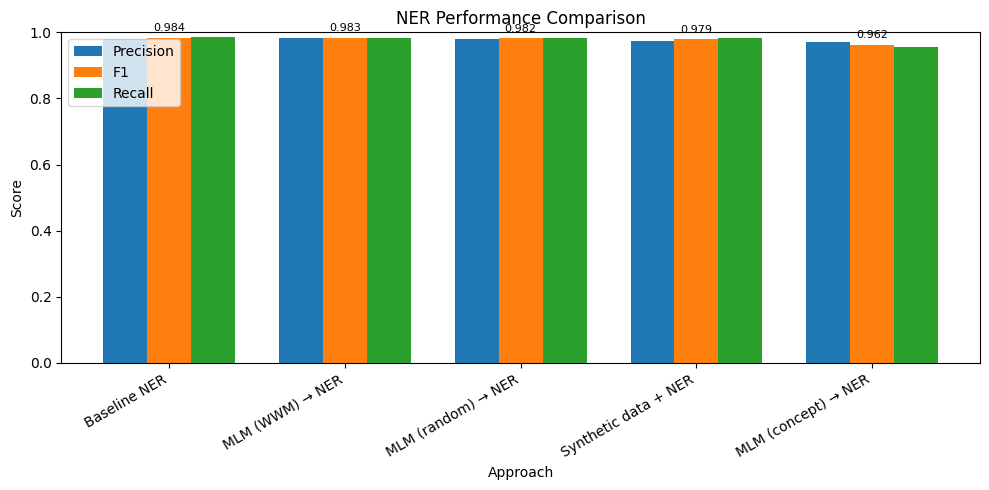

In [33]:
# Visualization
fig, ax = plt.subplots(figsize=(10, 5))

# Exclude "Before fine-tuning" for cleaner chart
plot_df = results_df[results_df["approach"] != "Before fine-tuning"].copy()

x = np.arange(len(plot_df))
width = 0.25

ax.bar(x - width, plot_df["precision"], width, label="Precision")
ax.bar(x, plot_df["f1"], width, label="F1")
ax.bar(x + width, plot_df["recall"], width, label="Recall")

ax.set_xlabel("Approach")
ax.set_ylabel("Score")
ax.set_title("NER Performance Comparison")
ax.set_xticks(x)
ax.set_xticklabels(plot_df["approach"], rotation=30, ha="right")
ax.legend()
ax.set_ylim(0, 1.0)

for i, row in enumerate(plot_df.itertuples()):
    ax.text(i, row.f1 + 0.02, f"{row.f1:.3f}", ha="center", fontsize=8)

plt.tight_layout()
plt.show()

## 8. Conclusions

*(Fill in after running experiments)*

## Results Summary

| Approach | F1 | Precision | Recall |
|---|---|---|---|
| Baseline NER | **0.9836** | 0.9803 | 0.9869 |
| MLM (WWM) → NER | 0.9829 | 0.9820 | 0.9838 |
| MLM (random) → NER | 0.9816 | 0.9812 | 0.9819 |
| Synthetic data + NER | 0.9787 | 0.9752 | 0.9821 |
| MLM (concept) → NER | 0.9619 | 0.9693 | 0.9546 |
| Before fine-tuning | 0.0408 | 0.0235 | 0.1561 |

## Key Observations

**Baseline NER** achieves the best overall F1 (0.9836), which is a strong result. `DeepPavlov/rubert-base-cased` is pre-trained on Russian Wikipedia and news — already closely aligned with FactRuEval's news domain — so further domain adaptation via MLM provides little gain.

**MLM pre-training (random and WWM)** performs nearly identically to the baseline (within 0.2 pp). The model already has strong Russian news representations, so additional in-domain MLM yields marginal improvements. WWM slightly outperforms random masking (0.9829 vs 0.9816), consistent with the finding that preventing subword shortcuts leads to better token representations.

**Synthetic data augmentation** (0.9787 F1) scores 0.5 pp below the baseline, despite adding ~10k pseudo-labeled examples from Lenta.ru via the XLM-RoBERTa-large teacher. This is expected: the pseudo-labels introduce noise that partially offsets the quantity benefit, and the teacher's output distribution differs slightly from FactRuEval's annotation guidelines.

**Concept masking** (0.9619 F1) underperforms all other approaches by a noticeable margin (−2.2 pp vs baseline). Entity-biased masking at 80% probability may be too aggressive: the model over-specializes on predicting entity tokens and loses general contextual representations that support both B- and I- tag prediction uniformly. The strategy is theoretically motivated but requires careful probability tuning to work in practice.

**Per-entity breakdown**: PER is the easiest entity type across all approaches (F1 ≥ 0.977), likely because Russian personal names are highly distinctive. ORG is the hardest (F1 as low as 0.933 for concept masking), which is common since organization names span a wide variety of surface forms.

## Conclusions

1. For a well-aligned pretrained model like `rubert-base-cased` on Russian news NER, fine-tuning directly on the target dataset is sufficient — domain-adaptive MLM pre-training provides only marginal gains.
2. Whole-word masking is a reliable improvement over token-level random masking when MLM pre-training is applied.
3. Synthetic data from a strong teacher model can be useful, but label noise limits gains; quality filtering or confidence thresholding could improve the results.
4. Concept masking needs careful probability calibration — too high an entity masking rate degrades general NER performance despite its theoretical appeal.